# Step 1: Explore NHANES Data for CRP Prediction

**Goal:** Understand the raw data before building a model.

We have 21 XPT files across 3 NHANES cycles. Let's explore one cycle first (`_I` = 2015-2016), then merge all three.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set_theme(style="darkgrid")
DATA_DIR = os.path.join("..", "data", "raw")

## 1.1 Load one cycle (2015-2016) and check each file

In [10]:
# Load all 7 files from the 2015-2016 cycle
crp = pd.read_sas(os.path.join(DATA_DIR, "HSCRP_I.XPT"), format="xport")
demo = pd.read_sas(os.path.join(DATA_DIR, "DEMO_I.XPT"), format="xport")
bmi = pd.read_sas(os.path.join(DATA_DIR, "BMX_I.XPT"), format="xport")
smoke = pd.read_sas(os.path.join(DATA_DIR, "SMQ_I.XPT"), format="xport")
sleep = pd.read_sas(os.path.join(DATA_DIR, "SLQ_I.XPT"), format="xport")
activity = pd.read_sas(os.path.join(DATA_DIR, "PAQ_I.XPT"), format="xport")
alcohol = pd.read_sas(os.path.join(DATA_DIR, "ALQ_I.XPT"), format="xport")

print(f"CRP:      {crp.shape[0]:,} rows, {crp.shape[1]} cols")
print(f"Demo:     {demo.shape[0]:,} rows, {demo.shape[1]} cols")
print(f"BMI:      {bmi.shape[0]:,} rows, {bmi.shape[1]} cols")
print(f"Smoking:  {smoke.shape[0]:,} rows, {smoke.shape[1]} cols")
print(f"Sleep:    {sleep.shape[0]:,} rows, {sleep.shape[1]} cols")
print(f"Activity: {activity.shape[0]:,} rows, {activity.shape[1]} cols")
print(f"Alcohol:  {alcohol.shape[0]:,} rows, {alcohol.shape[1]} cols")

CRP:      9,165 rows, 3 cols
Demo:     9,971 rows, 47 cols
BMI:      9,544 rows, 26 cols
Smoking:  7,001 rows, 42 cols
Sleep:    6,327 rows, 8 cols
Activity: 9,255 rows, 94 cols
Alcohol:  5,735 rows, 10 cols


## 1.2 Look at CRP (our target variable)

In [3]:
# LBXHSCRP = CRP value in mg/L
print("CRP columns:", list(crp.columns))
print()
print(crp["LBXHSCRP"].describe())
print(f"\nMissing: {crp['LBXHSCRP'].isna().sum()} / {len(crp)}")

CRP columns: ['SEQN', 'LBXHSCRP', 'LBDHRPLC']

count    7867.000000
mean        3.411364
std         7.515623
min         0.080000
25%         0.400000
50%         1.200000
75%         3.600000
max       188.500000
Name: LBXHSCRP, dtype: float64

Missing: 1298 / 9165


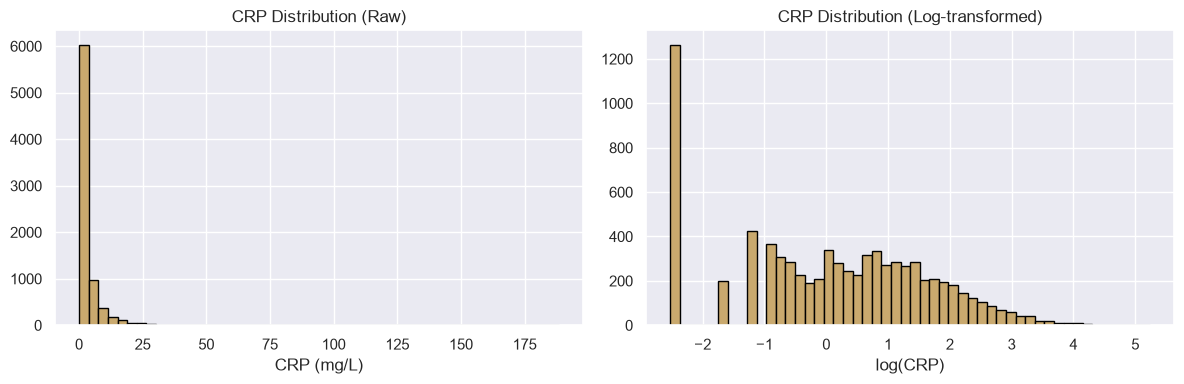

In [4]:
import numpy as np

# CRP distribution — expect heavy right skew
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

crp_values = crp["LBXHSCRP"].dropna()

axes[0].hist(crp_values, bins=50, color="#C9A96E", edgecolor="black")
axes[0].set_title("CRP Distribution (Raw)")
axes[0].set_xlabel("CRP (mg/L)")

axes[1].hist(np.log(crp_values.clip(lower=0.01)), bins=50, color="#C9A96E", edgecolor="black")
axes[1].set_title("CRP Distribution (Log-transformed)")
axes[1].set_xlabel("log(CRP)")

plt.tight_layout()
plt.show()

## 1.3 Check the feature columns we care about

In [5]:
# Key columns from each domain
key_cols = {
    "Demographics": {"RIDAGEYR": "Age", "RIAGENDR": "Gender (1=M, 2=F)"},
    "BMI": {"BMXBMI": "BMI", "BMXWAIST": "Waist circumference"},
    "Smoking": {"SMQ020": "Ever smoked 100 cigs", "SMQ040": "Current smoker"},
    "Sleep": {"SLD012": "Sleep hours/night", "SLQ050": "Ever told doctor trouble sleeping"},
    "Activity": {"PAQ605": "Vigorous work activity", "PAQ650": "Vigorous recreational activity", "PAD680": "Sedentary minutes/day"},
    "Alcohol": {"ALQ101": "Had 12+ drinks in life", "ALQ130": "Avg drinks/day past year"},
}

# Check each domain for missing values
for domain, cols in key_cols.items():
    print(f"\n{'='*40}")
    print(f"  {domain}")
    print(f"{'='*40}")
    
    if domain == "Demographics":
        df = demo
    elif domain == "BMI":
        df = bmi
    elif domain == "Smoking":
        df = smoke
    elif domain == "Sleep":
        df = sleep
    elif domain == "Activity":
        df = activity
    elif domain == "Alcohol":
        df = alcohol
    
    for col, desc in cols.items():
        if col in df.columns:
            missing = df[col].isna().sum()
            total = len(df)
            print(f"  {col} ({desc}): {missing}/{total} missing ({missing/total*100:.1f}%)")
            print(f"    Sample values: {df[col].dropna().head(5).tolist()}")
        else:
            print(f"  {col} ({desc}): COLUMN NOT FOUND")


  Demographics
  RIDAGEYR (Age): 0/9971 missing (0.0%)
    Sample values: [62.0, 53.0, 78.0, 56.0, 42.0]
  RIAGENDR (Gender (1=M, 2=F)): 0/9971 missing (0.0%)
    Sample values: [1.0, 1.0, 1.0, 2.0, 2.0]

  BMI
  BMXBMI (BMI): 788/9544 missing (8.3%)
    Sample values: [27.8, 30.8, 28.8, 42.4, 20.3]
  BMXWAIST (Waist circumference): 1231/9544 missing (12.9%)
    Sample values: [101.1, 107.9, 116.5, 110.1, 80.4]

  Smoking
  SMQ020 (Ever smoked 100 cigs): 1009/7001 missing (14.4%)
    Sample values: [1.0, 1.0, 1.0, 2.0, 2.0]
  SMQ040 (Current smoker): 4579/7001 missing (65.4%)
    Sample values: [3.0, 1.0, 3.0, 2.0, 1.0]

  Sleep
  SLD012 (Sleep hours/night): 33/6327 missing (0.5%)
    Sample values: [5.5, 8.0, 7.0, 6.5, 9.0]
  SLQ050 (Ever told doctor trouble sleeping): 0/6327 missing (0.0%)
    Sample values: [1.0, 2.0, 2.0, 1.0, 1.0]

  Activity
  PAQ605 (Vigorous work activity): 2289/9255 missing (24.7%)
    Sample values: [2.0, 2.0, 2.0, 2.0, 2.0]
  PAQ650 (Vigorous recreational a

## 1.4 Merge all domains on SEQN and check how many complete rows we get

In [6]:
# Select only the columns we need from each domain
crp_cols = crp[["SEQN", "LBXHSCRP"]]
demo_cols = demo[["SEQN", "RIDAGEYR", "RIAGENDR"]]
bmi_cols = bmi[["SEQN", "BMXBMI", "BMXWAIST"]]
smoke_cols = smoke[["SEQN", "SMQ020", "SMQ040"]]
sleep_cols = sleep[["SEQN", "SLD012", "SLQ050"]]
activity_cols = activity[["SEQN", "PAQ605", "PAQ650", "PAD680"]]
alcohol_cols = alcohol[["SEQN", "ALQ101", "ALQ130"]]

# Merge all on SEQN (inner join — only keep people who appear in ALL datasets)
merged = crp_cols.merge(demo_cols, on="SEQN")
merged = merged.merge(bmi_cols, on="SEQN")
merged = merged.merge(smoke_cols, on="SEQN", how="left")
merged = merged.merge(sleep_cols, on="SEQN", how="left")
merged = merged.merge(activity_cols, on="SEQN", how="left")
merged = merged.merge(alcohol_cols, on="SEQN", how="left")

print(f"Merged dataset: {merged.shape[0]:,} rows, {merged.shape[1]} columns")
print(f"\nMissing values per column:")
print(merged.isna().sum().to_string())
print(f"\nRows with NO missing values: {merged.dropna().shape[0]:,}")

Merged dataset: 9,165 rows, 15 columns

Missing values per column:
SEQN           0
LBXHSCRP    1298
RIDAGEYR       0
RIAGENDR       0
BMXBMI       409
BMXWAIST     852
SMQ020      3430
SMQ040      6846
SLD012      3130
SLQ050      3102
PAQ605      2463
PAQ650      2466
PAD680      2478
ALQ101      3957
ALQ130      5786

Rows with NO missing values: 1,445


## 1.5 Correlations — which features relate to CRP?

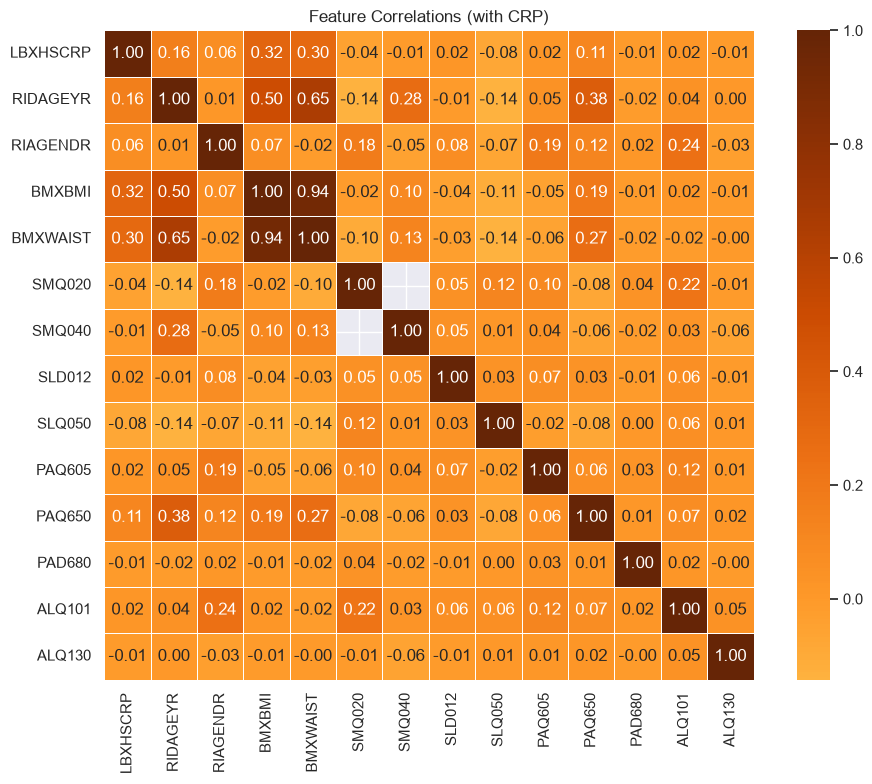


Correlation with CRP (LBXHSCRP):
BMXBMI      0.323663
BMXWAIST    0.300923
RIDAGEYR    0.160494
PAQ650      0.112356
RIAGENDR    0.064455
ALQ101      0.024130
SLD012      0.022645
PAQ605      0.018960
ALQ130     -0.005017
PAD680     -0.006160
SMQ040     -0.007581
SMQ020     -0.044344
SLQ050     -0.081545


In [7]:
# Correlation heatmap — how each feature relates to CRP
corr = merged.drop(columns=["SEQN"]).corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="YlOrBr", center=0, 
            square=True, linewidths=0.5)
plt.title("Feature Correlations (with CRP)")
plt.tight_layout()
plt.show()

# Print correlations with CRP specifically, sorted
print("\nCorrelation with CRP (LBXHSCRP):")
print(corr["LBXHSCRP"].drop("LBXHSCRP").sort_values(ascending=False).to_string())

## 1.6 CRP vs top features — scatter plots

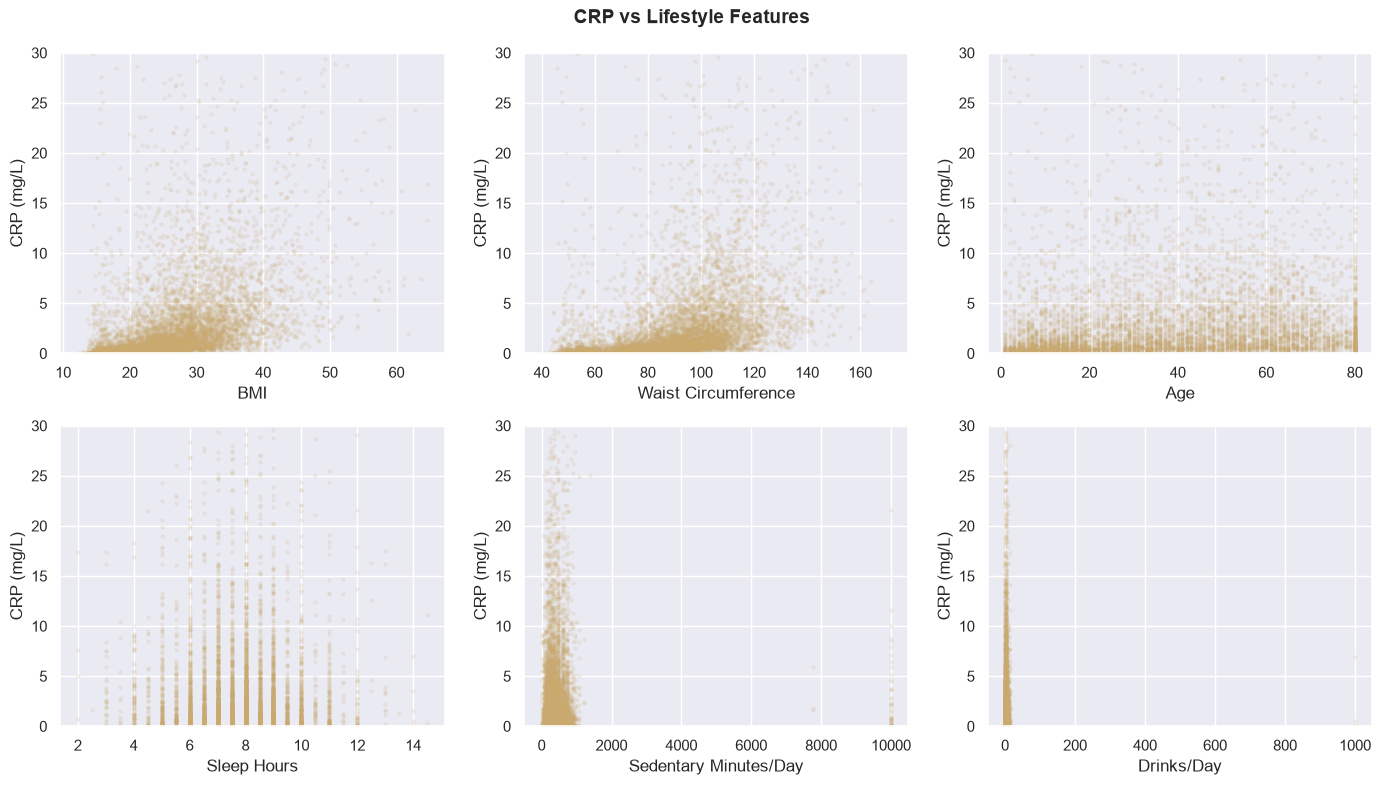

In [8]:
# Scatter plots of CRP vs the most likely predictors
fig, axes = plt.subplots(2, 3, figsize=(14, 8))

plots = [
    ("BMXBMI", "BMI"),
    ("BMXWAIST", "Waist Circumference"),
    ("RIDAGEYR", "Age"),
    ("SLD012", "Sleep Hours"),
    ("PAD680", "Sedentary Minutes/Day"),
    ("ALQ130", "Drinks/Day"),
]

for ax, (col, label) in zip(axes.flat, plots):
    data = merged[[col, "LBXHSCRP"]].dropna()
    ax.scatter(data[col], data["LBXHSCRP"], alpha=0.1, s=5, color="#C9A96E")
    ax.set_xlabel(label)
    ax.set_ylabel("CRP (mg/L)")
    ax.set_ylim(0, 30)

plt.suptitle("CRP vs Lifestyle Features", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 1.7 Summary stats of merged dataset

In [9]:
# Full summary of the merged dataset
print("Dataset shape:", merged.shape)
print()
merged.drop(columns=["SEQN"]).describe().round(2)

Dataset shape: (9165, 15)



,LBXHSCRP,RIDAGEYR,RIAGENDR,BMXBMI,BMXWAIST,SMQ020,SMQ040,SLD012,SLQ050,PAQ605,PAQ650,PAD680,ALQ101,ALQ130
count,7867.00,9165.00,9165.00,8756.00,8313.00,5735.00,2319.00,6035.00,6063.00,6702.00,6699.00,6687.00,5208.00,3379.00
mean,3.41,33.19,1.51,26.02,88.02,1.61,2.20,7.75,1.74,1.81,1.69,466.70,1.34,3.91
std,7.52,24.31,0.50,7.96,22.82,0.57,0.92,1.57,0.47,0.42,0.48,857.31,0.51,34.34
min,0.08,1.00,1.00,11.50,40.00,1.00,1.00,2.00,1.00,1.00,1.00,0.00,1.00,1.00
25%,0.40,11.00,1.00,19.90,71.70,1.00,1.00,7.00,1.00,2.00,1.00,240.00,1.00,1.00
50%,1.20,29.00,2.00,25.20,89.00,2.00,3.00,8.00,2.00,2.00,2.00,360.00,1.00,2.00
75%,3.60,54.00,2.00,30.60,103.60,2.00,3.00,8.50,2.00,2.00,2.00,540.00,2.00,3.00
max,188.50,80.00,2.00,67.30,171.60,9.00,3.00,14.50,9.00,9.00,9.00,9999.00,9.00,999.00


## Next Steps

After running this notebook, we'll know:
1. **How many participants** we have with complete data
2. **Which features** correlate most with CRP
3. **CRP's distribution** — confirms we need log-transform
4. **Missing value patterns** — which domains lose the most data

Take notes on what you see, then we'll move to `02_train.ipynb` where we:
- Load all 3 cycles (not just 2015-2016)
- Clean and engineer features
- Train the XGBoost model
- Evaluate accuracy